<a href="https://colab.research.google.com/github/keerthi5536/deep-learing/blob/main/AND_gate_with_hardcode_weights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AND GATE SINGLE PERCEPTRON - Hard coded weights
Weights : w1 = 1.0, w2 = 1.0
Bias : b = -1.5
Equation : 1.0*x1 + 1.0*x2 + -1.5 > 0

PREDICTIONS
[0 0] -> linear = -1.50 -> pred = 0 | actual = 0
[0 1] -> linear = -0.50 -> pred = 0 | actual = 0
[1 0] -> linear = -0.50 -> pred = 0 | actual = 0
[1 1] -> linear = 0.50 -> pred = 1 | actual = 1


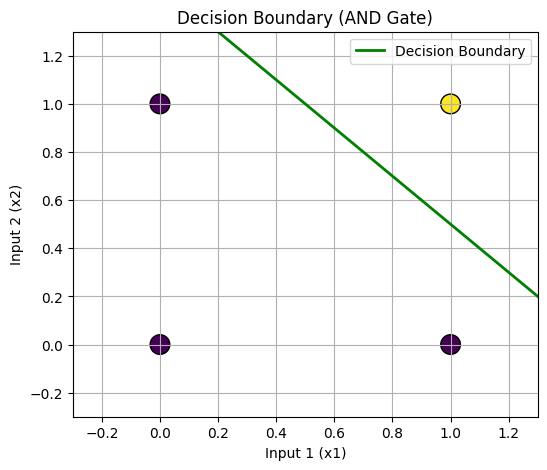


VERIFICATION RESULTS
[0 0] -> -1.50 -> class 0
[0 1] -> -0.50 -> class 0
[1 0] -> -0.50 -> class 0
[1 1] -> 0.50 -> class 1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Input and output for AND gate
x = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

y = np.array([[0],
              [0],
              [0],
              [1]])

print("AND GATE SINGLE PERCEPTRON - Hard coded weights")
print("=" * 60)

# Hard coded weights and bias
weights = np.array([[1.0],
                    [1.0]])

bias = np.array([[-1.5]])

print(f"Weights : w1 = {weights[0,0]}, w2 = {weights[1,0]}")
print(f"Bias : b = {bias[0,0]}")
print(f"Equation : {weights[0,0]}*x1 + {weights[1,0]}*x2 + {bias[0,0]} > 0")


# Step function
def step_function(u):
    return 1 if u > 0 else 0


# Perceptron prediction
def perceptron_predict(x, weights, bias):
    linear = np.dot(x, weights) + bias
    predictions = np.zeros((4, 1))

    for i in range(len(linear)):
        predictions[i, 0] = step_function(linear[i, 0])

    return predictions


# Sigmoid (optional)
def sigmoid_predict(x, weights, bias):
    linear_values = np.dot(x, weights) + bias
    return 1 / (1 + np.exp(-linear_values))


print("\nPREDICTIONS")

linear_values = np.dot(x, weights) + bias
predictions = perceptron_predict(x, weights, bias)

for i in range(len(x)):
    linear_val = linear_values[i, 0]
    pred = predictions[i, 0]
    actual = y[i, 0]

    print(f"{x[i]} -> linear = {linear_val:.2f} -> pred = {int(pred)} | actual = {int(actual)}")


# -----------------------
# Plot decision boundary
# -----------------------

plt.figure(figsize=(6, 5))

# scatter points
plt.scatter(x[:, 0], x[:, 1],
            c=y.flatten(),
            s=200,
            edgecolors='black')

# decision boundary
x1_range = np.linspace(-0.3, 1.3, 100)
x2_boundary = (-weights[0, 0] * x1_range - bias[0, 0]) / weights[1, 0]

plt.plot(x1_range, x2_boundary, 'g', linewidth=2, label="Decision Boundary")

plt.xlim(-0.3, 1.3)
plt.ylim(-0.3, 1.3)

plt.xlabel("Input 1 (x1)")
plt.ylabel("Input 2 (x2)")
plt.title("Decision Boundary (AND Gate)")
plt.grid(True)
plt.legend()

plt.show()


print("\nVERIFICATION RESULTS")

for i in range(len(x)):
    z = weights[0,0]*x[i,0] + weights[1,0]*x[i,1] + bias[0,0]

    if z > 0:
        cls = 1
    else:
        cls = 0

    print(f"{x[i]} -> {z:.2f} -> class {cls}")